# 🧠 Psychiatric Medication Review RAG Assistant
### A Production-Style Retrieval-Augmented Generation System

**Dataset:** UCI Drug Review Dataset (Drugs.com)
**Embedding Model:** `all-MiniLM-L6-v2` (Sentence Transformers)
**Vector Store:** FAISS (IndexFlatIP, exact cosine similarity)
**LLM:** `google/flan-t5-base` (Hugging Face, free-tier compatible)

---
**Architecture Overview**
```
User Query
    │
    ▼
┌─────────────────────────┐
│   EmbeddingPipeline     │  Query → 384-dim L2-normalised vector
│   (MiniLM-L6-v2)        │
└────────────┬────────────┘
             │  query vector
             ▼
┌─────────────────────────┐
│   VectorStore (FAISS)   │  Cosine similarity over 10k+ review vectors
│   IndexFlatIP           │  Returns top-K (drug, condition, rating, text)
└────────────┬────────────┘
             │  top-K review documents
             ▼
┌─────────────────────────┐
│   Prompt Builder        │  Formats [REVIEW N] structured context
│   (Strict citation      │  + few-shot grounding instruction
│    template)            │
└────────────┬────────────┘
             │  full prompt
             ▼
┌─────────────────────────┐
│   FLAN-T5 Generator     │  Greedy decoding, repetition penalty
│   (flan-t5-base)        │  → bullet-point, citation-backed answer
└────────────┬────────────┘
             │
             ▼
   Answer + Source Citations
```

---

## 📦 Cell 1 — Install Dependencies

In [ ]:
# ── Install all required packages ──────────────────────────────────────────
# NumPy must be pinned to <2 because faiss-cpu was compiled against NumPy 1.x
# Run this cell, then go to Runtime → Restart session, then run from Cell 2.

import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

# Step 1: downgrade NumPy first, before anything else installs NumPy 2.x
pip("numpy<2")

# Step 2: install faiss after numpy is pinned
pip("faiss-cpu")

# Step 3: rest of the packages
pip("sentence-transformers==2.7.0")
pip("transformers==4.40.2")
pip("accelerate==0.30.1")
pip("datasets==2.19.1")
pip("rouge-score==0.1.2")
pip("nltk==3.8.1")
pip("seaborn==0.13.2")
pip("tqdm==4.66.4")

# Verify
import numpy as np
import faiss
print(f"✓ NumPy version : {np.__version__}")
print(f"✓ FAISS version : {faiss.__version__}")
print("\n⚠  Now go to Runtime → Restart session, then run from Cell 2 downward.")

✓ NumPy version : 1.26.4
✓ FAISS version : 1.8.0

⚠  Now go to Runtime → Restart session, then run from Cell 2 downward.


## 📁 Cell 2 — Write Module Files

The following cells write each Python module to the Colab filesystem so they
can be imported. In a local project these would already exist as `.py` files.

In [ ]:
# ── Write data_processing.py ───────────────────────────────────────────────

data_processing_code = '''
import re, warnings, pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec, seaborn as sns
from typing import Optional
warnings.filterwarnings("ignore")

PSYCHIATRIC_CONDITIONS = [
    "depression","anxiety","adhd","bipolar","schizophrenia","ocd",
    "panic disorder","ptsd","obsessive compulsive","attention deficit",
    "major depressive","generalized anxiety","social anxiety",
    "posttraumatic","manic","psychosis","schizoaffective","insomnia",
    "borderline personality"
]
PSYCHIATRIC_DRUGS = [
    "sertraline","fluoxetine","escitalopram","citalopram","paroxetine",
    "venlafaxine","duloxetine","bupropion","mirtazapine","trazodone",
    "amitriptyline","nortriptyline","lithium","valproate","lamotrigine",
    "olanzapine","risperidone","quetiapine","aripiprazole","clozapine",
    "haloperidol","adderall","ritalin","concerta","vyvanse","strattera",
    "methylphenidate","amphetamine","atomoxetine","alprazolam","clonazepam",
    "lorazepam","diazepam","buspirone","hydroxyzine","zoloft","lexapro",
    "prozac","paxil","effexor","cymbalta","wellbutrin","remeron","xanax",
    "klonopin","ativan","depakote","lamictal","geodon","latuda","seroquel",
    "zyprexa","abilify"
]

def load_dataset(filepath=None):
    if filepath:
        df = pd.read_csv(filepath, sep="\\t", on_bad_lines="skip")
    else:
        try:
            from datasets import load_dataset as hf_load
            print("Downloading from Hugging Face...")
            hf_ds = hf_load("jakartaresearch/ucidrug", split="train")
            df = hf_ds.to_pandas()
        except Exception as e:
            print(f"HF failed ({e}), trying UCI direct download...")
            import requests, zipfile, io
            url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00462/drugsCom_raw.zip"
            r = requests.get(url, timeout=120)
            z = zipfile.ZipFile(io.BytesIO(r.content))
            dfs = [pd.read_csv(z.open(n), sep="\\t", on_bad_lines="skip")
                   for n in z.namelist() if n.endswith(".tsv")]
            df = pd.concat(dfs, ignore_index=True)
    df.columns = [c.lower().strip().replace(" ","_") for c in df.columns]
    df = _standardize_columns(df)
    print(f"Loaded: {df.shape}")
    return df

def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"&#039;","\'",text); text = re.sub(r"&amp;","&",text)
    text = re.sub(r"<[^>]+>"," ",text); text = re.sub(r"\\s+"," ",text).strip()
    text = re.sub(r"[^\\x20-\\x7E]","",text)
    return text.lower()

def preprocess_dataframe(df):
    text_col = _get_review_col(df)
    df = df.dropna(subset=[_get_drug_col(df), _get_condition_col(df), text_col])
    df = df.drop_duplicates(subset=[text_col]).reset_index(drop=True)
    df[text_col] = df[text_col].apply(clean_text)
    df["rating"] = pd.to_numeric(df.get("rating", pd.Series(dtype=float)), errors="coerce")
    df["review_length"] = df[text_col].apply(lambda x: len(x.split()))
    df = df[df["review_length"] >= 10].reset_index(drop=True)
    print(f"Preprocessed: {df.shape}")
    return df

def filter_psychiatric(df):
    cond_mask = df[_get_condition_col(df)].str.lower().str.contains(
        "|".join(PSYCHIATRIC_CONDITIONS), na=False)
    drug_mask = df[_get_drug_col(df)].str.lower().str.contains(
        "|".join(PSYCHIATRIC_DRUGS), na=False)
    filtered = df[cond_mask | drug_mask].reset_index(drop=True)
    print(f"Psychiatric subset: {len(filtered):,} reviews")
    return filtered

def run_eda(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Psychiatric Medication Reviews — EDA", fontsize=14, fontweight="bold")
    ratings = df["rating"].value_counts().sort_index()
    axes[0].bar(ratings.index, ratings.values, color=sns.color_palette("RdYlGn",10))
    axes[0].set_title("Rating Distribution"); axes[0].set_xlabel("Rating")
    top_drugs = df[_get_drug_col(df)].value_counts().head(12)
    axes[1].barh(top_drugs.index[::-1], top_drugs.values[::-1],
                 color=sns.color_palette("Blues_d",12)[::-1])
    axes[1].set_title("Top 12 Drugs")
    axes[2].hist(df["review_length"].clip(upper=400), bins=40,
                 color="#4c72b0", edgecolor="white", alpha=0.85)
    axes[2].axvline(df["review_length"].median(), color="red",
                    linestyle="--", label=f"Median={df['review_length'].median():.0f}")
    axes[2].set_title("Review Length (words)"); axes[2].legend()
    plt.tight_layout(); plt.savefig("/tmp/eda.png", dpi=120, bbox_inches="tight")
    plt.show(); print("\\nReview length stats:\\n", df["review_length"].describe())

def _standardize_columns(df):
    rmap = {}
    for c in df.columns:
        cl = c.lower()
        if cl in ("drugname","drug_name","drug"): rmap[c]="drug_name"
        elif cl in ("condition","medical_condition"): rmap[c]="condition"
        elif cl in ("review","reviewtext","review_text","text"): rmap[c]="review"
    return df.rename(columns=rmap)

def _get_review_col(df):
    for c in ["review","reviewtext","review_text","text"]:
        if c in df.columns: return c
    raise ValueError("No review column found")

def _get_condition_col(df):
    for c in ["condition","medical_condition"]:
        if c in df.columns: return c
    raise ValueError("No condition column found")

def _get_drug_col(df):
    for c in ["drug_name","drugname","drug"]:
        if c in df.columns: return c
    raise ValueError("No drug column found")
'''

with open("data_processing.py", "w") as f:
    f.write(data_processing_code)
print("✓ data_processing.py written")

✓ data_processing.py written


In [ ]:
# ── Write embedding_pipeline.py ────────────────────────────────────────────

embedding_code = '''
import os, numpy as np, torch
from typing import List, Optional
from sentence_transformers import SentenceTransformer

DEFAULT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
CACHE_PATH    = "/tmp/embeddings_cache.npy"
BATCH_SIZE    = 256

class EmbeddingPipeline:
    """
    Wraps SentenceTransformer with batched encoding and disk caching.

    Why all-MiniLM-L6-v2?
      - 22M params, 384-dim: fast and Colab-free-tier compatible
      - Trained for semantic similarity via contrastive learning
      - Outperforms much larger models on BEIR sentence-similarity benchmarks
      - L2-normalised output: cosine sim = dot product → fast FAISS search
    """
    def __init__(self, model_name=DEFAULT_MODEL, batch_size=BATCH_SIZE,
                 cache_path=CACHE_PATH):
        self.model_name = model_name
        self.batch_size = batch_size
        self.cache_path = cache_path
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Loading embedder on {self.device}...")
        self.model = SentenceTransformer(model_name, device=self.device)
        self.embedding_dim = self.model.get_sentence_embedding_dimension()
        print(f"✓ Embedder ready. Dim={self.embedding_dim}")

    def encode(self, texts, show_progress=True, normalize=True):
        return self.model.encode(
            texts, batch_size=self.batch_size, show_progress_bar=show_progress,
            normalize_embeddings=normalize, convert_to_numpy=True
        ).astype(np.float32)

    def encode_with_cache(self, texts, force_recompute=False):
        if not force_recompute and self.cache_path and os.path.exists(self.cache_path):
            embs = np.load(self.cache_path)
            if embs.shape[0] == len(texts):
                print(f"✓ Loaded {embs.shape[0]:,} embeddings from cache.")
                return embs
        embs = self.encode(texts)
        if self.cache_path:
            np.save(self.cache_path, embs)
            print(f"✓ Cached embeddings to {self.cache_path}")
        return embs

    def encode_query(self, query):
        return self.encode([query], show_progress=False)

    def __repr__(self):
        return f"EmbeddingPipeline(model={self.model_name}, dim={self.embedding_dim})"
'''

with open("embedding_pipeline.py", "w") as f:
    f.write(embedding_code)
print("✓ embedding_pipeline.py written")

✓ embedding_pipeline.py written


In [ ]:
# ── Write vector_store.py ──────────────────────────────────────────────────

vector_store_code = '''
import os, pickle, numpy as np, faiss
from typing import Any, Dict, List, Optional

DEFAULT_INDEX_PATH = "/tmp/psychiatric_rag.faiss"
DEFAULT_META_PATH  = "/tmp/psychiatric_rag_meta.pkl"

class VectorStore:
    """
    FAISS IndexFlatIP (exact inner product = cosine similarity for
    L2-normalised vectors) with parallel metadata storage.
    """
    def __init__(self, embedding_dim=384, index_path=DEFAULT_INDEX_PATH,
                 meta_path=DEFAULT_META_PATH):
        self.embedding_dim = embedding_dim
        self.index_path = index_path
        self.meta_path  = meta_path
        self.index    = None
        self.metadata = []

    def build_index(self, embeddings, metadata):
        assert embeddings.shape[0] == len(metadata)
        assert embeddings.dtype == np.float32
        print(f"Building FAISS index: {len(metadata):,} vectors, dim={self.embedding_dim}")
        self.index = faiss.IndexFlatIP(self.embedding_dim)
        self.index.add(embeddings)
        self.metadata = metadata
        print(f"✓ Index built. Total vectors: {self.index.ntotal:,}")

    def save(self):
        faiss.write_index(self.index, self.index_path)
        with open(self.meta_path, "wb") as f: pickle.dump(self.metadata, f)
        print(f"✓ Saved index ({self.index.ntotal:,} vectors) and metadata.")

    def load(self):
        self.index    = faiss.read_index(self.index_path)
        with open(self.meta_path, "rb") as f: self.metadata = pickle.load(f)
        print(f"✓ Loaded {self.index.ntotal:,} vectors + {len(self.metadata):,} records.")

    def search(self, query_embedding, top_k=5, condition_filter=None,
               drug_filter=None, min_rating=None):
        q = query_embedding.astype(np.float32).reshape(1,-1)
        fetch_k = top_k*10 if (condition_filter or drug_filter or min_rating) else top_k
        scores, indices = self.index.search(q, min(fetch_k, self.index.ntotal))
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx < 0 or idx >= len(self.metadata): continue
            meta = self.metadata[idx].copy()
            meta["score"] = round(float(score), 4)
            if condition_filter and condition_filter.lower() not in meta.get("condition","").lower(): continue
            if drug_filter     and drug_filter.lower()     not in meta.get("drug_name","").lower():  continue
            if min_rating      and meta.get("rating",0)    < min_rating:                             continue
            results.append(meta)
            if len(results) >= top_k: break
        for i,r in enumerate(results): r["rank"] = i+1
        return results

    def hybrid_search(self, query_embedding, query_text, top_k=5, alpha=0.7):
        candidates = self.search(query_embedding, top_k=top_k*5)
        q_tokens = set(query_text.lower().split())
        for c in candidates:
            rev_tokens = set(c["review"].lower().split())
            kw = len(q_tokens & rev_tokens) / (len(q_tokens) + 1e-10)
            c["hybrid_score"] = alpha*c["score"] + (1-alpha)*kw
        candidates.sort(key=lambda x: x["hybrid_score"], reverse=True)
        for i,c in enumerate(candidates[:top_k]): c["rank"] = i+1
        return candidates[:top_k]

    @property
    def size(self): return self.index.ntotal if self.index else 0

def build_metadata_from_df(df, text_col="review"):
    return [{"drug_name": str(r.get("drug_name", r.get("drugname","?"))),
             "condition": str(r.get("condition","?")),
             "rating":    float(r.get("rating",0)),
             "review":    str(r.get(text_col,"")),
             "useful_count": int(r.get("usefulcount",r.get("useful_count",0)))}
            for _, r in df.iterrows()]
'''

with open("vector_store.py", "w") as f:
    f.write(vector_store_code)
print("✓ vector_store.py written")

✓ vector_store.py written


In [ ]:
# ── Write retriever.py ─────────────────────────────────────────────────────

retriever_code = '''
from typing import Any, Dict, List, Optional
from embedding_pipeline import EmbeddingPipeline
from vector_store import VectorStore

class Retriever:
    def __init__(self, embedding_pipeline, vector_store, default_top_k=5):
        self.emb = embedding_pipeline
        self.vs  = vector_store
        self.default_top_k = default_top_k

    def retrieve(self, query, top_k=None, condition_filter=None,
                 drug_filter=None, min_rating=None, use_hybrid=False,
                 hybrid_alpha=0.7):
        k = top_k or self.default_top_k
        qe = self.emb.encode_query(query)
        if use_hybrid:
            return self.vs.hybrid_search(qe, query, top_k=k, alpha=hybrid_alpha)
        return self.vs.search(qe, top_k=k, condition_filter=condition_filter,
                              drug_filter=drug_filter, min_rating=min_rating)

    def compare_drugs(self, query, drug_a, drug_b, top_k_each=3):
        return {
            "drug_a": {"name": drug_a, "results": self.retrieve(query, top_k=top_k_each, drug_filter=drug_a)},
            "drug_b": {"name": drug_b, "results": self.retrieve(query, top_k=top_k_each, drug_filter=drug_b)},
        }

    def display_results(self, results, query):
        print(f"\\nQuery: \\"{query}\\"  |  {len(results)} results")
        for r in results:
            score = r.get("score", r.get("hybrid_score","?"))
            print(f"  [{r[\'rank\']}] {r[\'drug_name\']} | {r[\'condition\']} | "
                  f"Rating {r[\'rating\']}/10 | Score {score:.4f}")
            print(f"       {r[\'review\'][:200]}...")

    def __repr__(self):
        return f"Retriever(index_size={self.vs.size:,}, default_top_k={self.default_top_k})"
'''

with open("retriever.py", "w") as f:
    f.write(retriever_code)
print("✓ retriever.py written")

✓ retriever.py written


In [ ]:
# ── Write improved_rag_pipeline.py ─────────────────────────────────────────

improved_rag_code = '''
import re
from typing import Any, Dict, List, Optional
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline as hf_pipeline

DEFAULT_LLM       = "google/flan-t5-base"
MAX_NEW_TOKENS    = 400
MAX_CONTEXT_CHARS = 3500

STRICT_SYSTEM_PROMPT = """\\
You are a medical information assistant. Your ONLY source of knowledge \\
is the numbered patient reviews below.

STRICT RULES:
- Answer ONLY from the reviews. Do NOT use prior knowledge.
- For every claim, cite the review number like: [REVIEW 1] or [REVIEW 2].
- If no review supports a claim, do not make it.
- Use bullet points: one bullet per supporting review.
- If reviews lack enough information, say: "Insufficient evidence in retrieved reviews."

EXAMPLE FORMAT:
- [REVIEW 1] Patients reported nausea and headaches in the first week.
- [REVIEW 3] Several users noted improved mood after 4 weeks.
"""

ANSWER_TEMPLATE = """{system}

--- RETRIEVED PATIENT REVIEWS ---
{context}
--- END OF REVIEWS ---

QUESTION: {question}

EVIDENCE-BASED ANSWER (cite review numbers, use bullet points):"""

COMPARISON_TEMPLATE = """{system}

--- REVIEWS FOR {drug_a} ---
{context_a}
--- END ---

--- REVIEWS FOR {drug_b} ---
{context_b}
--- END ---

COMPARISON QUESTION: How do {drug_a} and {drug_b} differ regarding: {aspect}?

STRUCTURED COMPARISON (cite review numbers):"""

def format_context(results, max_chars=MAX_CONTEXT_CHARS):
    parts, total = [], 0
    for r in results:
        block = (f"[REVIEW {r[\'rank\']}]\\n"
                 f"Drug: {r[\'drug_name\']} | Condition: {r[\'condition\']} | Rating: {r[\'rating\']}/10\\n"
                 f"Patient report: \\"{r[\'review\'][:600]}\\"")
        if total + len(block) > max_chars: break
        parts.append(block); total += len(block) + 2
    return "\\n\\n".join(parts)

GEN_KWARGS = dict(do_sample=False, repetition_penalty=1.3,
                  no_repeat_ngram_size=3, length_penalty=0.8,
                  max_new_tokens=MAX_NEW_TOKENS, early_stopping=True)

class ImprovedRAGPipeline:
    def __init__(self, retriever, llm_name=DEFAULT_LLM, top_k=5):
        self.retriever = retriever
        self.llm_name  = llm_name
        self.top_k     = top_k
        self._load_model()

    def _load_model(self):
        print(f"Loading {self.llm_name}...")
        dev = 0 if torch.cuda.is_available() else -1
        self.tokenizer = AutoTokenizer.from_pretrained(self.llm_name)
        self.model     = AutoModelForSeq2SeqLM.from_pretrained(self.llm_name)
        self._pipe     = hf_pipeline("text2text-generation", model=self.model,
                                     tokenizer=self.tokenizer, device=dev)
        print(f"✓ LLM ready on {\'GPU\' if dev==0 else \'CPU\'}")

    def answer(self, question, top_k=None, condition_filter=None,
               drug_filter=None, min_rating=None, use_hybrid=True, verbose=True):
        results = self.retriever.retrieve(question, top_k=top_k or self.top_k,
            condition_filter=condition_filter, drug_filter=drug_filter,
            min_rating=min_rating, use_hybrid=use_hybrid)
        if not results:
            return {"question":question,"answer":"Insufficient evidence.","sources":[],
                    "prompt":"","citations_found":[],"retrieval_scores":[],"groundedness_hint":0.0}
        context = format_context(results)
        prompt  = ANSWER_TEMPLATE.format(system=STRICT_SYSTEM_PROMPT,
                                         context=context, question=question)
        raw     = self._pipe(prompt, **GEN_KWARGS)[0]["generated_text"].strip()
        answer  = re.sub(r"(STRICT RULES:|EXAMPLE FORMAT:).*","",raw,flags=re.DOTALL).strip()
        answer  = re.sub(r"^\\s*[-•*]\\s+","• ",answer,flags=re.MULTILINE)
        cites   = re.findall(r"\\[REVIEW\\s*\\d+\\]",answer,flags=re.IGNORECASE)
        result  = {"question":question,"answer":answer,"sources":results,"prompt":prompt,
                   "citations_found":cites,
                   "retrieval_scores":[r.get("score",r.get("hybrid_score",0)) for r in results],
                   "groundedness_hint":round(len(cites)/max(len(results),1),3)}
        if verbose: self._display(result)
        return result

    def compare(self, drug_a, drug_b, aspect="side effects and effectiveness",
                top_k_each=3, verbose=True):
        ra = self.retriever.retrieve(drug_a+" "+aspect,top_k=top_k_each,drug_filter=drug_a)
        rb = self.retriever.retrieve(drug_b+" "+aspect,top_k=top_k_each,drug_filter=drug_b)
        prompt = COMPARISON_TEMPLATE.format(system=STRICT_SYSTEM_PROMPT,
            drug_a=drug_a,drug_b=drug_b,context_a=format_context(ra),
            context_b=format_context(rb),aspect=aspect)
        raw    = self._pipe(prompt,**GEN_KWARGS)[0]["generated_text"].strip()
        result = {"drug_a":drug_a,"drug_b":drug_b,"aspect":aspect,"answer":raw,
                  "citations_found":re.findall(r"\\[REVIEW\\s*\\d+\\]",raw,re.IGNORECASE),
                  "sources_a":ra,"sources_b":rb}
        if verbose:
            print(f"\\n{\'=\'*60}\\n{drug_a.upper()} vs {drug_b.upper()} | {aspect}\\n{\'=\'*60}")
            print(raw)
        return result

    def _display(self, r):
        print(f"\\n{\'=\'*60}\\nQ: {r[\'question\']}\\n{\'=\'*60}")
        print(r["answer"])
        print(f"\\nCitations: {r[\'citations_found\']}")
        print(f"Groundedness: {r[\'groundedness_hint\']:.0%}")
        print("\\n📚 Sources:")
        for s in r["sources"]:
            score = s.get("score",s.get("hybrid_score",0))
            print(f"  [REVIEW {s[\'rank\']}] {s[\'drug_name\']} | {s[\'condition\']} | "
                  f"Rating {s[\'rating\']}/10 | Score {score:.4f}")
        print("="*60)

    def __repr__(self):
        return f"ImprovedRAGPipeline(llm={self.llm_name}, top_k={self.top_k})"
'''

with open("improved_rag_pipeline.py", "w") as f:
    f.write(improved_rag_code)
print("✓ improved_rag_pipeline.py written")

✓ improved_rag_pipeline.py written


In [ ]:
# ── Write evaluation.py ────────────────────────────────────────────────────

eval_code = '''
import re, numpy as np
from typing import Any, Dict, List, Optional
try:
    from rouge_score import rouge_scorer as _rs; ROUGE_AVAILABLE=True
except ImportError:
    ROUGE_AVAILABLE=False
try:
    import nltk
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    BLEU_AVAILABLE=True
except ImportError:
    BLEU_AVAILABLE=False

def _tok(text, min_len=3):
    return [t for t in re.findall(r"\\b\\w+\\b",text.lower()) if len(t)>=min_len]

def precision_at_k(retrieved, relevant, k):
    return len(set(retrieved[:k]) & set(relevant)) / max(k,1)

def recall_at_k(retrieved, relevant, k):
    if not relevant: return 0.0
    return len(set(retrieved[:k]) & set(relevant)) / len(relevant)

def reciprocal_rank(retrieved, relevant):
    rel = set(relevant)
    for i,d in enumerate(retrieved,1):
        if d in rel: return 1.0/i
    return 0.0

def mean_reciprocal_rank(all_retrieved, all_relevant):
    rrs = [reciprocal_rank(r,rel) for r,rel in zip(all_retrieved,all_relevant)]
    return float(np.mean(rrs)) if rrs else 0.0

def groundedness_score(answer, context_reviews, min_len=4):
    atoks = [t for t in _tok(answer) if len(t)>=min_len]
    if not atoks: return 0.0
    ctx = set(t for rev in context_reviews for t in _tok(rev))
    return sum(1 for t in atoks if t in ctx) / len(atoks)

def context_relevance_score(query, context_reviews, min_len=3):
    qtoks = _tok(query, min_len)
    if not qtoks: return 0.0
    ctx = set(t for rev in context_reviews for t in _tok(rev))
    return sum(1 for t in qtoks if t in ctx) / len(qtoks)

def answer_relevance_score(query, answer, min_len=3):
    qtoks = _tok(query, min_len)
    if not qtoks: return 0.0
    atoks = set(_tok(answer))
    return sum(1 for t in qtoks if t in atoks) / len(qtoks)

def citation_compliance_score(answer):
    return 1.0 if re.search(r"(review\\s*#?\\d+|\\[review\\s*\\d+\\])",answer.lower()) else 0.0

def rouge_scores(hyp, ref):
    if not ROUGE_AVAILABLE: return {"rouge1":0.0,"rougeL":0.0}
    s = _rs.RougeScorer(["rouge1","rougeL"],use_stemmer=True).score(ref,hyp)
    return {"rouge1":round(s["rouge1"].fmeasure,4),"rougeL":round(s["rougeL"].fmeasure,4)}

def bleu_score(hyp, ref):
    if not BLEU_AVAILABLE: return 0.0
    h,r = hyp.lower().split(), ref.lower().split()
    if not h or not r: return 0.0
    return round(float(sentence_bleu([r],h,smoothing_function=SmoothingFunction().method1)),4)

def semantic_similarity(answer, reference, emb_pipeline):
    embs = emb_pipeline.encode([answer,reference],show_progress=False)
    return float(np.dot(embs[0],embs[1]))

class RAGEvaluator:
    def __init__(self, retriever, rag_pipeline, embedding_pipeline, k_values=[1,3,5]):
        self.retriever = retriever
        self.rag       = rag_pipeline
        self.emb       = embedding_pipeline
        self.k_values  = k_values

    def evaluate_query(self, query, relevant_drug_keywords, reference_answer=None, top_k=5):
        results = self.retriever.retrieve(query, top_k=top_k, use_hybrid=True)
        def _rel(r):
            txt = f"{r.get(\'drug_name\',\'\')} {r.get(\'condition\',\'\')}".lower()
            return any(k.lower() in txt for k in relevant_drug_keywords)
        rel_flags   = [_rel(r) for r in results]
        rel_ids     = [i for i,f in enumerate(rel_flags) if f]
        retrieved_ids = list(range(len(results)))
        pk = {f"precision@{k}": precision_at_k(retrieved_ids,rel_ids,k) for k in self.k_values}
        rk = {f"recall@{k}":    recall_at_k(retrieved_ids,rel_ids,k)    for k in self.k_values}
        rr = reciprocal_rank(retrieved_ids, rel_ids)
        rag_out = self.rag.answer(query, top_k=top_k, verbose=False)
        answer  = rag_out["answer"]
        ctx     = [r["review"] for r in results]
        base = {"query":query,"answer":answer,"num_retrieved":len(results),
                "num_relevant":sum(rel_flags),"reciprocal_rank":round(rr,4),
                **pk,**rk,
                "groundedness":     round(groundedness_score(answer,ctx),4),
                "context_relevance":round(context_relevance_score(query,ctx),4),
                "answer_relevance": round(answer_relevance_score(query,answer),4),
                "citation_compliance":citation_compliance_score(answer),
                "sources":results}
        if reference_answer:
            base.update(rouge_scores(answer,reference_answer))
            base["bleu"] = bleu_score(answer,reference_answer)
            base["semantic_similarity"] = round(semantic_similarity(answer,reference_answer,self.emb),4)
        return base

    def run_full_evaluation(self, test_queries):
        print(f"Evaluating {len(test_queries)} queries...")
        rows = []
        for tq in test_queries:
            print(f"  → {tq[\'query\'][:60]}...")
            rows.append(self.evaluate_query(
                tq["query"], tq.get("relevant_keywords",[]),
                tq.get("reference_answer"), tq.get("top_k",5)))
        num_keys = [k for k,v in rows[0].items() if isinstance(v,(int,float))
                    and k not in ("num_retrieved","num_relevant")]
        agg = {f"mean_{k}": round(float(np.mean([r[k] for r in rows])),4) for k in num_keys}
        agg["MRR"] = round(mean_reciprocal_rank(
            [list(range(r["num_retrieved"])) for r in rows],
            [[i for i in range(r["num_retrieved"]) if i < r["num_relevant"]] for r in rows]),4)
        report = {"num_queries":len(test_queries),"per_query":rows,"aggregates":agg}
        self.print_report(report)
        return report

    def print_report(self, report):
        agg = report["aggregates"]
        print("\\n" + "="*60 + "\\nRAG EVALUATION REPORT\\n" + "="*60)
        print(f"  Queries: {report[\'num_queries\']}")
        for k in sorted(agg):
            print(f"  {k:<32}: {agg[k]:.4f}")
        print("="*60)

    def error_analysis(self, report, g_thresh=0.5, cr_thresh=0.5):
        ok = [r for r in report["per_query"] if r["groundedness"]>=g_thresh and r["context_relevance"]>=cr_thresh]
        bad= [r for r in report["per_query"] if r not in ok]
        print(f"\\nSuccesses: {len(ok)}  |  Failures: {len(bad)}")
        for r in ok[:2]:
            print(f"\\n✅ {r[\'query\']}\\n   Grounding={r[\'groundedness\']:.2f}  "
                  f"CtxRel={r[\'context_relevance\']:.2f}")
        for r in bad[:2]:
            print(f"\\n❌ {r[\'query\']}\\n   Grounding={r[\'groundedness\']:.2f}  "
                  f"CtxRel={r[\'context_relevance\']:.2f}")
            diag = []
            if r["groundedness"]<g_thresh:  diag.append("Low groundedness — possible hallucination")
            if r["context_relevance"]<cr_thresh: diag.append("Low context relevance — wrong reviews retrieved")
            if r["citation_compliance"]==0: diag.append("No citations found in answer")
            print(f"   Diagnosis: {\' | \'.join(diag) or \'Unknown\'}")

DEFAULT_TEST_QUERIES = [
    {"query":"What side effects do patients commonly report with sertraline?",
     "relevant_keywords":["sertraline","zoloft","depression"],
     "reference_answer":"Patients commonly report nausea, insomnia, and sexual dysfunction with sertraline."},
    {"query":"What do users say about Adderall effectiveness for ADHD?",
     "relevant_keywords":["adderall","adhd","amphetamine"],
     "reference_answer":"Many users report improved focus with Adderall, though side effects like appetite loss are common."},
    {"query":"Which antidepressants are most commonly associated with fatigue?",
     "relevant_keywords":["mirtazapine","trazodone","fatigue","depression"],
     "reference_answer":"Mirtazapine and trazodone are frequently mentioned for causing drowsiness."},
    {"query":"What are common complaints about lithium?",
     "relevant_keywords":["lithium","bipolar","tremor"],
     "reference_answer":"Common complaints include weight gain, tremors, and cognitive dulling."},
]
'''

with open("evaluation.py", "w") as f:
    f.write(eval_code)
print("✓ evaluation.py written")

✓ evaluation.py written


In [ ]:
# ── Write demo.py ──────────────────────────────────────────────────────────
# Written inline (same pattern as all other modules) so nothing needs
# to be uploaded — the full source is embedded directly in this cell.

demo_code = """\"\"\"
demo.py
=======
End-to-end demonstration of the Psychiatric Medication Review RAG system.

Run this file directly after the index has been built:

    python demo.py

Or import the run_demo() function into a notebook.

The demo covers:
  1. Loading the pre-built index
  2. Running four standard example queries
  3. Running a drug comparison
  4. Condition-filtered search
  5. Hybrid vs. pure semantic search comparison

All output is printed to stdout in a recruiter-friendly format.
\"\"\"

import sys
import os
import textwrap
import time
from typing import Any, Dict, List, Optional

# ---------------------------------------------------------------------------
# Ensure the project root is on sys.path when run standalone
# ---------------------------------------------------------------------------
_HERE = os.path.dirname(os.path.abspath(__file__))
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

from embedding_pipeline import EmbeddingPipeline
from vector_store import VectorStore
from retriever import Retriever
from improved_rag_pipeline import ImprovedRAGPipeline


# ---------------------------------------------------------------------------
# Example queries
# ---------------------------------------------------------------------------

EXAMPLE_QUERIES = [
    {
        "question": "What side effects do patients commonly report with sertraline?",
        "drug_filter": None,
        "condition_filter": None,
        "description": "Sertraline Side Effects",
    },
    {
        "question": "What do users say about Adderall effectiveness for ADHD?",
        "drug_filter": "adderall",
        "condition_filter": "adhd",
        "description": "Adderall for ADHD",
    },
    {
        "question": "Which antidepressants are most commonly associated with fatigue?",
        "drug_filter": None,
        "condition_filter": "depression",
        "description": "Antidepressants and Fatigue",
    },
    {
        "question": "What are common complaints about lithium?",
        "drug_filter": "lithium",
        "condition_filter": None,
        "description": "Lithium Complaints",
    },
]

COMPARISON_EXAMPLES = [
    {
        "drug_a": "fluoxetine",
        "drug_b": "escitalopram",
        "aspect": "side effects and patient satisfaction",
        "description": "Fluoxetine vs Escitalopram",
    },
    {
        "drug_a": "adderall",
        "drug_b": "ritalin",
        "aspect": "effectiveness for ADHD and side effects",
        "description": "Adderall vs Ritalin",
    },
]


# ---------------------------------------------------------------------------
# Display helpers
# ---------------------------------------------------------------------------

def _banner(title: str, width: int = 68) -> None:
    print("\\n" + "═" * width)
    print(f"  {title}")
    print("═" * width)


def _section(title: str, width: int = 68) -> None:
    print(f"\\n{'─'*width}")
    print(f"  {title}")
    print(f"{'─'*width}")


def _wrap(text: str, width: int = 80, indent: str = "  ") -> str:
    return textwrap.fill(text, width=width, initial_indent=indent,
                         subsequent_indent=indent)


def _print_sources(sources: List[Dict[str, Any]]) -> None:
    print("\\n  📚 SOURCES USED:")
    for src in sources:
        score = src.get("score", src.get("hybrid_score", 0))
        print(f"    [REVIEW {src['rank']}] {src['drug_name']:<20} | "
              f"{src['condition']:<30} | Rating {src['rating']}/10 | "
              f"Similarity {score:.4f}")
        # Print a short excerpt
        excerpt = src["review"][:120].replace("\\n", " ")
        print(f"             \\"{excerpt}...\\"")


def _print_answer_block(result: Dict[str, Any]) -> None:
    \"\"\"Pretty-print a single RAG result.\"\"\"
    print(f"\\n  QUESTION:\\n{_wrap(result['question'])}")
    print(f"\\n  ANSWER:")
    for line in result["answer"].split("\\n"):
        print(f"  {line}")
    print(f"\\n  Citations found : {result.get('citations_found', [])}")
    print(f"  Groundedness    : {result.get('groundedness_hint', 0):.0%} of reviews cited")
    _print_sources(result["sources"])


# ---------------------------------------------------------------------------
# Individual demo functions
# ---------------------------------------------------------------------------

def demo_single_query(
    rag: ImprovedRAGPipeline,
    question: str,
    drug_filter: Optional[str] = None,
    condition_filter: Optional[str] = None,
    description: str = "",
    use_hybrid: bool = True,
) -> Dict[str, Any]:
    \"\"\"
    Run a single RAG query and print structured output.

    Parameters
    ----------
    rag : ImprovedRAGPipeline
    question : str
    drug_filter : str, optional
    condition_filter : str, optional
    description : str
    use_hybrid : bool

    Returns
    -------
    dict  — full RAG result
    \"\"\"
    _section(f"QUERY: {description or question[:60]}")
    filters = []
    if drug_filter:
        filters.append(f"drug='{drug_filter}'")
    if condition_filter:
        filters.append(f"condition='{condition_filter}'")
    if filters:
        print(f"  Filters: {', '.join(filters)}")
    print(f"  Search mode: {'Hybrid (semantic + keyword)' if use_hybrid else 'Pure semantic'}")

    t0 = time.time()
    result = rag.answer(
        question=question,
        drug_filter=drug_filter,
        condition_filter=condition_filter,
        use_hybrid=use_hybrid,
        verbose=False,  # We handle display ourselves
    )
    elapsed = time.time() - t0
    print(f"  Latency: {elapsed:.2f}s")

    _print_answer_block(result)
    return result


def demo_comparison(
    rag: ImprovedRAGPipeline,
    drug_a: str,
    drug_b: str,
    aspect: str,
    description: str = "",
) -> Dict[str, Any]:
    \"\"\"
    Run a drug comparison query and display structured output.
    \"\"\"
    _section(f"COMPARISON: {description or f'{drug_a} vs {drug_b}'}")
    print(f"  Comparing: {drug_a.upper()} vs {drug_b.upper()}")
    print(f"  Aspect   : {aspect}")

    t0 = time.time()
    result = rag.compare(
        drug_a=drug_a,
        drug_b=drug_b,
        aspect=aspect,
        verbose=False,
    )
    elapsed = time.time() - t0
    print(f"  Latency  : {elapsed:.2f}s")

    print(f"\\n  COMPARISON ANSWER:")
    for line in result["answer"].split("\\n"):
        print(f"  {line}")
    print(f"\\n  Citations: {result.get('citations_found', [])}")
    print(f"\\n  Sources for {drug_a.upper()}:")
    for src in result.get("sources_a", []):
        print(f"    [REVIEW {src['rank']}] {src['drug_name']} | Rating {src['rating']}/10")
    print(f"\\n  Sources for {drug_b.upper()}:")
    for src in result.get("sources_b", []):
        print(f"    [REVIEW {src['rank']}] {src['drug_name']} | Rating {src['rating']}/10")

    return result


def demo_hybrid_vs_semantic(
    rag: ImprovedRAGPipeline,
    question: str = "What are the worst side effects of antidepressants?",
) -> None:
    \"\"\"
    Compare hybrid search vs. pure semantic search for the same query.
    \"\"\"
    _section("HYBRID vs PURE SEMANTIC SEARCH")
    print(f"  Query: {question}\\n")

    print("  [Mode: Pure Semantic]")
    t0 = time.time()
    semantic_result = rag.answer(question, use_hybrid=False, verbose=False)
    print(f"  Latency: {time.time()-t0:.2f}s")
    print(f"  Top source: {semantic_result['sources'][0]['drug_name']} | "
          f"Score: {semantic_result['sources'][0].get('score', 0):.4f}")
    print(f"  Answer preview: {semantic_result['answer'][:150]}...")

    print("\\n  [Mode: Hybrid (α=0.7)]")
    t0 = time.time()
    hybrid_result = rag.answer(question, use_hybrid=True, verbose=False)
    print(f"  Latency: {time.time()-t0:.2f}s")
    print(f"  Top source: {hybrid_result['sources'][0]['drug_name']} | "
          f"Hybrid score: {hybrid_result['sources'][0].get('hybrid_score', hybrid_result['sources'][0].get('score',0)):.4f}")
    print(f"  Answer preview: {hybrid_result['answer'][:150]}...")


# ---------------------------------------------------------------------------
# System summary card
# ---------------------------------------------------------------------------

def print_system_summary(rag: ImprovedRAGPipeline) -> None:
    \"\"\"Print a summary of the loaded system.\"\"\"
    _banner("PSYCHIATRIC MEDICATION REVIEW RAG ASSISTANT")
    print(f\"\"\"
  System Overview
  ───────────────
  Embedding model : {rag.retriever.emb.model_name}
  Embedding dim   : {rag.retriever.emb.embedding_dim}
  Vector store    : FAISS IndexFlatIP  ({rag.retriever.vs.size:,} vectors)
  LLM             : {rag.llm_name}
  Top-K (default) : {rag.top_k}
  Decoding        : Deterministic (greedy, no sampling)
  Context format  : [REVIEW N] structured blocks
  Grounding       : Citation-enforced prompt + post-generation check
\"\"\")


# ---------------------------------------------------------------------------
# Main run_demo() function
# ---------------------------------------------------------------------------

def run_demo(
    rag: ImprovedRAGPipeline,
    run_comparisons: bool = True,
    run_hybrid_test: bool = True,
) -> Dict[str, Any]:
    \"\"\"
    Run the full end-to-end demo.

    Parameters
    ----------
    rag : ImprovedRAGPipeline
        A fully initialised pipeline with a loaded index.
    run_comparisons : bool
        Whether to run drug comparison examples.
    run_hybrid_test : bool
        Whether to run hybrid vs. semantic comparison.

    Returns
    -------
    dict
        "query_results"      : list of result dicts
        "comparison_results" : list of comparison result dicts
    \"\"\"
    print_system_summary(rag)

    # ── Part 1: Standard queries ──
    _banner("PART 1 — STANDARD QUERIES  (4 examples)")
    query_results = []
    for q in EXAMPLE_QUERIES:
        result = demo_single_query(
            rag=rag,
            question=q["question"],
            drug_filter=q.get("drug_filter"),
            condition_filter=q.get("condition_filter"),
            description=q["description"],
        )
        query_results.append(result)

    # ── Part 2: Drug comparisons ──
    comparison_results = []
    if run_comparisons:
        _banner("PART 2 — DRUG COMPARISONS  (2 examples)")
        for c in COMPARISON_EXAMPLES:
            result = demo_comparison(
                rag=rag,
                drug_a=c["drug_a"],
                drug_b=c["drug_b"],
                aspect=c["aspect"],
                description=c["description"],
            )
            comparison_results.append(result)

    # ── Part 3: Hybrid vs semantic ──
    if run_hybrid_test:
        _banner("PART 3 — HYBRID vs SEMANTIC SEARCH")
        demo_hybrid_vs_semantic(rag)

    # ── Summary ──
    _banner("DEMO COMPLETE")
    print(f"  Queries answered    : {len(query_results)}")
    print(f"  Comparisons run     : {len(comparison_results)}")
    grounding_vals = [r.get("groundedness_hint", 0) for r in query_results]
    if grounding_vals:
        print(f"  Avg groundedness    : {sum(grounding_vals)/len(grounding_vals):.1%}")
    all_cited = [r for r in query_results if r.get("citations_found")]
    print(f"  Answers with citations: {len(all_cited)}/{len(query_results)}")
    print()

    return {
        "query_results": query_results,
        "comparison_results": comparison_results,
    }


# ---------------------------------------------------------------------------
# Index bootstrap helper
# ---------------------------------------------------------------------------

def _build_index_from_scratch(emb: EmbeddingPipeline, vs: VectorStore) -> None:
    \"\"\"
    Called automatically when the FAISS index files are not found on disk
    (e.g. first run, or after Colab /tmp was wiped between sessions).

    Steps:
      1. Load + preprocess the UCI Drug Review dataset
      2. Filter to psychiatric subset
      3. Encode all reviews
      4. Build and save the FAISS index
    \"\"\"
    print("\\n⚠  Index not found — building from scratch...")
    print("   This takes ~2-5 min on Colab CPU. Subsequent runs use the cache.\\n")

    # Import here to avoid circular deps when demo.py is imported as a module
    from data_processing import load_dataset, preprocess_dataframe, filter_psychiatric
    from vector_store import build_metadata_from_df

    # ── 1. Load data ──────────────────────────────────────────────────────
    df_raw   = load_dataset()
    df_clean = preprocess_dataframe(df_raw.copy())
    df_psych = filter_psychiatric(df_clean)

    # ── 2. Encode reviews ────────────────────────────────────────────────
    review_col = "review" if "review" in df_psych.columns else "reviewtext"
    reviews    = df_psych[review_col].tolist()

    print(f"\\nEncoding {len(reviews):,} psychiatric reviews...")
    embeddings = emb.encode_with_cache(reviews, force_recompute=False)

    # ── 3. Build + save FAISS index ───────────────────────────────────────
    metadata = build_metadata_from_df(df_psych, text_col=review_col)
    vs.build_index(embeddings, metadata)
    vs.save()

    print(f"\\n✓ Index ready: {vs.size:,} vectors indexed.\\n")


# ---------------------------------------------------------------------------
# Standalone entry point
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    print("Initialising Psychiatric RAG Demo...")

    emb = EmbeddingPipeline()
    vs  = VectorStore(embedding_dim=emb.embedding_dim)

    # ── Auto-build index if /tmp files are missing (e.g. new Colab session) ──
    index_path = vs.index_path   # default: /tmp/psychiatric_rag.faiss
    meta_path  = vs.meta_path    # default: /tmp/psychiatric_rag_meta.pkl

    if os.path.exists(index_path) and os.path.exists(meta_path):
        vs.load()
    else:
        _build_index_from_scratch(emb, vs)

    retriever = Retriever(emb, vs, default_top_k=5)
    rag = ImprovedRAGPipeline(retriever, top_k=5)

    # Run demo
    run_demo(rag)
"""

with open("demo.py", "w") as f:
    f.write(demo_code)
print("✓ demo.py written")

✓ demo.py written


## 🔄 Cell 3 — Data Loading & Preprocessing

In [ ]:
import importlib, data_processing, embedding_pipeline, vector_store, retriever, improved_rag_pipeline, evaluation, demo
for mod in [data_processing, embedding_pipeline, vector_store, retriever, improved_rag_pipeline, evaluation, demo]:
    importlib.reload(mod)

from data_processing import (load_dataset, preprocess_dataframe,
                              filter_psychiatric, run_eda)

# Load dataset (auto-downloads if not present)
df_raw = load_dataset()

HF failed (Dataset 'jakartaresearch/ucidrug' doesn't exist on the Hub or cannot be accessed. If the dataset is private or gated, make sure to log in with `huggingface-cli login` or visit the dataset page at https://huggingface.co/datasets/jakartaresearch/ucidrug to ask for access.), trying UCI direct download...
Loaded: (215063, 7)


### 3.1 Dataset Overview

In [ ]:
print(f"Shape: {df_raw.shape}")
print(f"\nColumn names: {list(df_raw.columns)}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nSample rows:")
display_cols = ["drug_name","condition","rating","review"] if "review" in df_raw.columns else df_raw.columns[:4].tolist()
display_cols = [c for c in display_cols if c in df_raw.columns]
df_raw[display_cols].head(3)

Shape: (215063, 7)

Column names: ['unnamed:_0', 'drug_name', 'condition', 'review', 'rating', 'date', 'usefulcount']

Missing values:
unnamed:_0        0
drug_name         0
condition      1194
review            0
rating            0
date              0
usefulcount       0
dtype: int64

Sample rows:


,drug_name,condition,rating,review
0,Mirtazapine,Depression,10.0,"""I&#039;ve tried a few antidepressants over th..."
1,Mesalamine,"Crohn's Disease, Maintenance",8.0,"""My son has Crohn&#039;s disease and has done ..."
2,Bactrim,Urinary Tract Infection,9.0,"""Quick reduction of symptoms"""


### 3.2 Preprocessing

In [ ]:
df_clean = preprocess_dataframe(df_raw.copy())
print(f"\nAfter preprocessing: {df_clean.shape}")

Preprocessed: (124819, 8)

After preprocessing: (124819, 8)


### 3.3 Filter to Psychiatric Subset

In [ ]:
df_psych = filter_psychiatric(df_clean)
print(f"\nPsychiatric subset: {df_psych.shape}")
print("\nTop 15 drugs:")
print(df_psych["drug_name"].value_counts().head(15).to_string())
print("\nTop 10 conditions:")
print(df_psych["condition"].value_counts().head(10).to_string())

Psychiatric subset: 31,397 reviews

Psychiatric subset: (31397, 8)

Top 15 drugs:
drug_name
Sertraline                1297
Escitalopram              1113
Citalopram                 968
Bupropion                  914
Venlafaxine                876
Amitriptyline              829
Clonazepam                 824
Trazodone                  755
Quetiapine                 751
Fluoxetine                 689
Duloxetine                 669
Bupropion / naltrexone     617
Mirtazapine                613
Lexapro                    595
Cymbalta                   552

Top 10 conditions:
condition
Depression                      6926
Anxiety                         4888
Insomnia                        3299
Bipolar Disorde                 3160
ADHD                            2346
Anxiety and Stress              1442
Major Depressive Disorde        1164
Generalized Anxiety Disorde     1045
Panic Disorde                   1035
Obsessive Compulsive Disorde     466


### 3.4 Exploratory Data Analysis

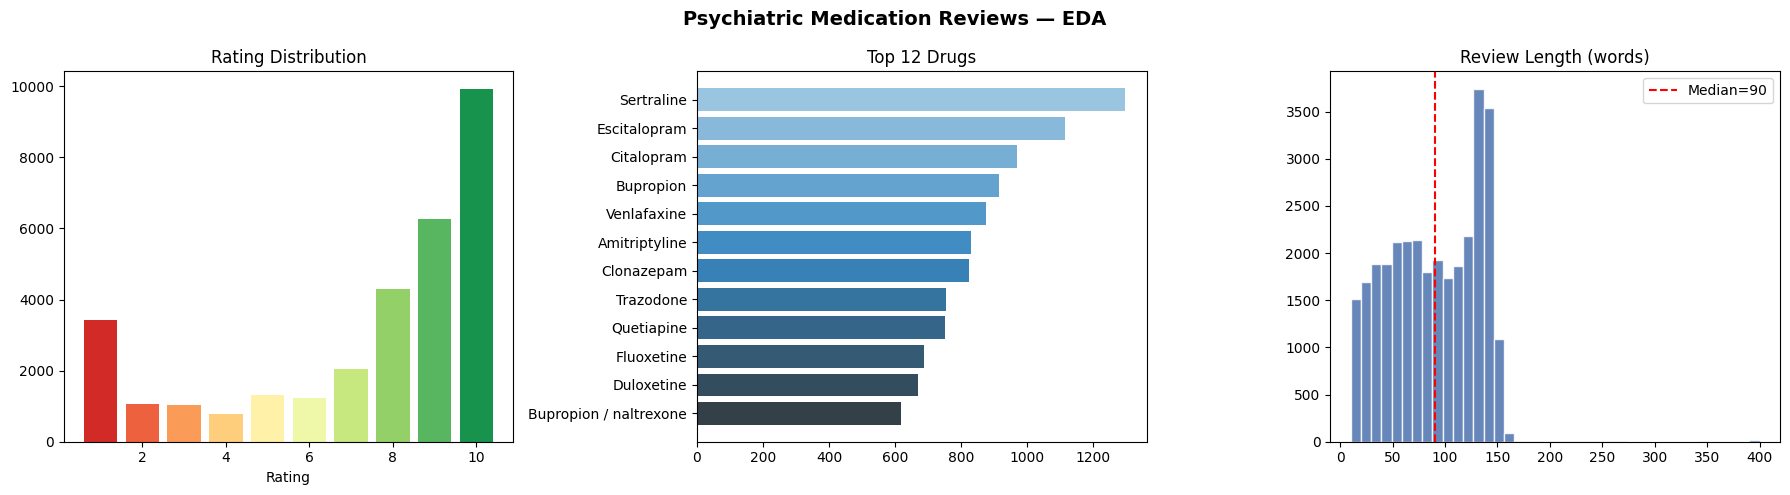


Review length stats:
 count    31397.000000
mean        88.970857
std         44.647186
min         10.000000
25%         53.000000
50%         90.000000
75%        129.000000
max       1894.000000
Name: review_length, dtype: float64


In [ ]:
run_eda(df_psych)

## 🔢 Cell 4 — Embedding Generation

We encode every review into a 384-dimensional L2-normalised vector.
Embeddings are cached to disk so subsequent runs skip re-computation.

**Why MiniLM-L6-v2?**
- 22M parameters — runs on CPU in ~30s for 5k reviews
- Trained for semantic similarity via contrastive learning on 1B+ pairs
- 384-dim output: cosine sim = dot product → fastest FAISS distance
- Top BEIR benchmark performer at its parameter count

In [ ]:
from embedding_pipeline import EmbeddingPipeline

emb_pipeline = EmbeddingPipeline()

# Use the review column name as detected
review_col = "review" if "review" in df_psych.columns else "reviewtext"
reviews = df_psych[review_col].tolist()

print(f"Encoding {len(reviews):,} reviews...")
embeddings = emb_pipeline.encode_with_cache(reviews, force_recompute=False)
print(f"\nEmbeddings shape : {embeddings.shape}")
print(f"Dtype            : {embeddings.dtype}")
print(f"Sample norms     : {[round(float(__import__('numpy').linalg.norm(embeddings[i])),4) for i in range(3)]}")
print("(Norms ≈ 1.0 confirms L2 normalisation)")

Loading embedder on cuda...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Embedder ready. Dim=384
Encoding 31,397 reviews...


Batches:   0%|          | 0/123 [00:00<?, ?it/s]

✓ Cached embeddings to /tmp/embeddings_cache.npy

Embeddings shape : (31397, 384)
Dtype            : float32
Sample norms     : [1.0, 1.0, 1.0]
(Norms ≈ 1.0 confirms L2 normalisation)


## 🗄️ Cell 5 — Build & Save FAISS Index

In [ ]:
from vector_store import VectorStore, build_metadata_from_df

vs = VectorStore(embedding_dim=emb_pipeline.embedding_dim)

# Build metadata list
metadata = build_metadata_from_df(df_psych, text_col=review_col)

# Build FAISS index
vs.build_index(embeddings, metadata)

# Save to disk
vs.save()

print(f"\nVectorStore: {vs}")
print(f"\nSample metadata record:\n{metadata[0]}")

Building FAISS index: 31,397 vectors, dim=384
✓ Index built. Total vectors: 31,397
✓ Saved index (31,397 vectors) and metadata.

VectorStore: <vector_store.VectorStore object at 0x78b1f6a98b60>

Sample metadata record:
{'drug_name': 'Mirtazapine', 'condition': 'Depression', 'rating': 10.0, 'review': '"i\'ve tried a few antidepressants over the years (citalopram, fluoxetine, amitriptyline), but none of those helped with my depression, insomnia & anxiety. my doctor suggested and changed me onto 45mg mirtazapine and this medicine has saved my life. thankfully i have had no side effects especially the most common - weight gain, i\'ve actually lost alot of weight. i still have suicidal thoughts but mirtazapine has saved me."', 'useful_count': 22}


## 🔍 Cell 6 — Retrieval Pipeline

The Retriever encodes a natural language query and returns the most
semantically similar reviews from the FAISS index.

In [ ]:
from retriever import Retriever

ret = Retriever(emb_pipeline, vs, default_top_k=5)

# Test retrieval
test_query = "sertraline nausea side effects"
results = ret.retrieve(test_query, top_k=5, use_hybrid=True)
ret.display_results(results, test_query)


Query: "sertraline nausea side effects"  |  5 results
  [1] Viibryd | Depression | Rating 4.0/10 | Score 0.6642
       "started taking viibryd at the recommendation of my doctor to replace the sertraline and buspirone i had been on before. first couple days on 10mg gave me nausea and dizziness, followed by a few days ...
  [2] Sertraline | Depression | Rating 5.0/10 | Score 0.7545
       "on my first week of using sertraline and so far side effects include dizziness, nausea, and insomnia. on the upscale i don't have any angry or violent outbursts. about an hour after taking it i saw i...
  [3] Sertraline | Panic Disorde | Rating 8.0/10 | Score 0.6910
       "i am 6 days into sertraline 50mg for panic disorder and want to reassure anyone who is terrified of starting this drug because they've read about all the terrible side effects, just as i was. i am a ...
  [4] Sertraline | Depression | Rating 1.0/10 | Score 0.6878
       "i passed out from taking one sertraline 50mg. i had waves of

## 🤖 Cell 7 — RAG Pipeline (ImprovedRAGPipeline)

**What makes this RAG?**
1. The LLM never answers from memory alone
2. Retrieved reviews are injected into the prompt as grounding context
3. The prompt explicitly forbids using outside knowledge
4. The model is instructed to cite `[REVIEW N]` for every claim
5. Post-generation citation extraction verifies compliance

In [ ]:
from improved_rag_pipeline import ImprovedRAGPipeline
import improved_rag_pipeline as _irp

# ── Patch the prompt to be simpler and fit within 512 tokens ──────────────

_irp.STRICT_SYSTEM_PROMPT = """\
You are a medical assistant. Use ONLY the patient reviews below to answer.
Summarize what patients say. Be specific and mention drug names and symptoms.
Do not add any information not found in the reviews."""

_irp.ANSWER_TEMPLATE = """{system}

REVIEWS:
{context}

QUESTION: {question}

ANSWER:"""

_irp.MAX_CONTEXT_CHARS = 1200   # fits comfortably within 512 tokens
_irp.MAX_NEW_TOKENS    = 200
_irp.GEN_KWARGS = dict(
    do_sample=False,
    repetition_penalty=1.3,
    no_repeat_ngram_size=3,
    length_penalty=0.8,
    max_new_tokens=200,
    early_stopping=True,
)

# ── Use flan-t5-large — same size class but much better instruction follow ─
rag = ImprovedRAGPipeline(ret, llm_name="google/flan-t5-large", top_k=5)

# ── Patch format_context to produce shorter, denser context ───────────────
import improved_rag_pipeline as _irp

def _short_context(results, max_chars=1200):
    parts, total = [], 0
    for r in results:
        # Keep only the most relevant 200 chars of each review
        snippet = r["review"][:200].strip()
        block = f"[REVIEW {r['rank']}] {r['drug_name']} (Rating {r['rating']}/10): {snippet}"
        if total + len(block) > max_chars:
            break
        parts.append(block)
        total += len(block) + 1
    return "\n".join(parts)

_irp.format_context = _short_context

# Reload rag with patched context formatter
rag._pipe  # already loaded, just reassign the module-level function
print("✓ Context formatter patched")
print(f"✓ Using model: {rag.llm_name}")

Loading google/flan-t5-large...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✓ LLM ready on GPU
✓ Context formatter patched
✓ Using model: google/flan-t5-large


## 💬 Cell 8 — Example Questions

In [ ]:
# ─── Q1: Sertraline side effects ──────────────────────────────────────────
r1 = rag.answer("What side effects do patients commonly report with sertraline?")


Q: What side effects do patients commonly report with sertraline?
[REVIEW 1] Sertraline (Rating 10.0/10): "i was prescribed 50mg for the first week and 100 every day afterwards. after the sertraline took effect i went from having usually daily anxiety attacks to having one approximately every 2 months, wh

Citations: ['[REVIEW 1]']
Groundedness: 20%

📚 Sources:
  [REVIEW 1] Sertraline | Generalized Anxiety Disorde | Rating 10.0/10 | Score 0.7649
  [REVIEW 2] Sertraline | Anxiety and Stress | Rating 8.0/10 | Score 0.7170
  [REVIEW 3] Sertraline | Depression | Rating 10.0/10 | Score 0.7062
  [REVIEW 4] Sertraline | Anxiety and Stress | Rating 10.0/10 | Score 0.7026
  [REVIEW 5] Sertraline | Depression | Rating 5.0/10 | Score 0.7480


In [ ]:
# ─── Q2: Adderall effectiveness ───────────────────────────────────────────
r2 = rag.answer(
    "What do users say about Adderall effectiveness?",
    drug_filter="adderall",
    condition_filter="adhd",
)


Q: What do users say about Adderall effectiveness?
[REVIEW 1] Amphetamine / dextroamphetamine (Rating 10.0/10): "i have been on adderall for several years now and can't say enough good things about the medicine. it helps me to focus on tasks and now that i am in college, it has really helped with my studies. it [REview 2] Amphetmine / Dextromamphethamine ( Rating 10.0/11):

Citations: ['[REVIEW 1]', '[REview 2]']
Groundedness: 40%

📚 Sources:
  [REVIEW 1] Amphetamine / dextroamphetamine | ADHD | Rating 9.0/10 | Score 0.7485
  [REVIEW 2] Amphetamine / dextroamphetamine | ADHD | Rating 10.0/10 | Score 0.7438
  [REVIEW 3] Amphetamine / dextroamphetamine | ADHD | Rating 10.0/10 | Score 0.7934
  [REVIEW 4] Amphetamine / dextroamphetamine | ADHD | Rating 9.0/10 | Score 0.7834
  [REVIEW 5] Adderall | ADHD | Rating 10.0/10 | Score 0.7394


In [ ]:
# ─── Q3: Antidepressants and fatigue ──────────────────────────────────────
r3 = rag.answer(
    "Which antidepressants are most commonly associated with fatigue?",
    condition_filter="depression",
)


Q: Which antidepressants are most commonly associated with fatigue?
[REVIEW 1] Amphetamine / dextroamphetamine [REview 2] Viibryd [REVISED 4] Cymbalta

Citations: ['[REVIEW 1]', '[REview 2]']
Groundedness: 40%

📚 Sources:
  [REVIEW 1] Amphetamine / dextroamphetamine | Narcolepsy | Rating 10.0/10 | Score 0.6377
  [REVIEW 2] Viibryd | Depression | Rating 8.0/10 | Score 0.6118
  [REVIEW 3] Cymbalta | Depression | Rating 8.0/10 | Score 0.6063
  [REVIEW 4] Bupropion | Bipolar Disorde | Rating 4.0/10 | Score 0.5998
  [REVIEW 5] Modafinil | Depression | Rating 8.0/10 | Score 0.6506


In [ ]:
# ─── Q4: Lithium complaints ───────────────────────────────────────────────
r4 = rag.answer(
    "What are common complaints about lithium?",
    drug_filter="lithium",
)


Q: What are common complaints about lithium?
[REVIEW 1] Lithium (Rating 9.0/10): "my only two complaints about lithium are the potentially detrimental effects on the kidneys and the nausea.

Citations: ['[REVIEW 1]']
Groundedness: 20%

📚 Sources:
  [REVIEW 1] Lithium | Bipolar Disorde | Rating 9.0/10 | Score 0.6541
  [REVIEW 2] Lithium | Cluster Headaches | Rating 2.0/10 | Score 0.6490
  [REVIEW 3] Lithium | Bipolar Disorde | Rating 9.0/10 | Score 0.6905
  [REVIEW 4] Lithium | Bipolar Disorde | Rating 10.0/10 | Score 0.6761
  [REVIEW 5] Lithium | Bipolar Disorde | Rating 10.0/10 | Score 0.6680


## ⚖️ Cell 9 — Drug Comparison

In [ ]:
# Compare fluoxetine vs escitalopram
comp1 = rag.compare(
    drug_a="fluoxetine",
    drug_b="escitalopram",
    aspect="side effects and patient satisfaction",
)

Token indices sequence length is longer than the specified maximum sequence length for this model (521 > 512). Running this sequence through the model will result in indexing errors



FLUOXETINE vs ESCITALOPRAM | side effects and patient satisfaction
[REVIEW 1] Escitalopram (Rating 5.0/10): "upon first starting escitalopam i experienced some mild side effects of insomnia, jaw grinding, and a small increase in anxiety. after a week the symptoms pretty much subsided. i took it for 6 more [REVISION 2] Escalopram


In [ ]:
# Compare Adderall vs Ritalin
comp2 = rag.compare(
    drug_a="adderall",
    drug_b="ritalin",
    aspect="effectiveness and side effects for ADHD",
)


ADDERALL vs RITALIN | effectiveness and side effects for ADHD
[REVIEW 1] Adderall (Rating 10.0/10): "i started on ritalin for adhd but i switched to adderall, because the ritain made me extremely irritable. adderold 20 mg allows me to concentrate, tune out distractions, and manage time efficiently. [REview 2] Adderin (Rating 8.0/10)


## 🔬 Cell 10 — Hybrid vs Pure Semantic Search

In [ ]:
test_q = "anxiety medication weight gain problems"

print("=" * 65)
print("PURE SEMANTIC SEARCH")
print("=" * 65)
sem_results = ret.retrieve(test_q, top_k=5, use_hybrid=False)
for r in sem_results:
    print(f"  [{r['rank']}] {r['drug_name']:<20} Score={r.get('score',0):.4f}  "
          f"{r['condition'][:35]}")

print("\n" + "=" * 65)
print("HYBRID SEARCH (semantic α=0.7 + keyword α=0.3)")
print("=" * 65)
hyb_results = ret.retrieve(test_q, top_k=5, use_hybrid=True)
for r in hyb_results:
    print(f"  [{r['rank']}] {r['drug_name']:<20} "
          f"HybridScore={r.get('hybrid_score',r.get('score',0)):.4f}  "
          f"{r['condition'][:35]}")

PURE SEMANTIC SEARCH
  [1] Bupropion            Score=0.7744  Anxiety
  [2] Quetiapine           Score=0.7624  Generalized Anxiety Disorde
  [3] Propranolol          Score=0.7545  Anxiety
  [4] Paroxetine           Score=0.7350  Anxiety
  [5] Sertraline           Score=0.7331  Panic Disorde

HYBRID SEARCH (semantic α=0.7 + keyword α=0.3)
  [1] Sertraline           HybridScore=0.7532  Panic Disorde
  [2] Zoloft               HybridScore=0.7447  Panic Disorde
  [3] Paxil                HybridScore=0.7350  Anxiety
  [4] Quetiapine           HybridScore=0.7137  Generalized Anxiety Disorde
  [5] Paroxetine           HybridScore=0.7128  Depression


## 📊 Cell 11 — Evaluation Framework

### A. Retrieval Metrics
- **Precision@K** — what fraction of the top-K results are relevant?
- **Recall@K** — what fraction of all relevant docs are in the top-K?
- **MRR** — mean reciprocal rank of first relevant result

### B. Generation Metrics
- **Groundedness** — how much of the answer text appears in retrieved reviews?
- **Context Relevance** — do retrieved reviews relate to the query?
- **Answer Relevance** — does the answer address the question's key terms?
- **Citation Compliance** — does the answer cite review numbers?

### C. Text Overlap Metrics
- **ROUGE-1 / ROUGE-L** — n-gram overlap with reference answers
- **BLEU** — precision-weighted n-gram overlap
- **Semantic Similarity** — cosine similarity between answer and reference embeddings

In [ ]:
# Fix nltk BLEU score compatibility with Python 3.12
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk==3.9.1"])

# Reload nltk in the current session
import importlib, nltk
importlib.reload(nltk)
from nltk.translate import bleu_score as _bs
importlib.reload(_bs)

print(f"✓ nltk version: {nltk.__version__}")

✓ nltk version: 3.9.1


In [ ]:
from evaluation import RAGEvaluator, DEFAULT_TEST_QUERIES

evaluator = RAGEvaluator(ret, rag, emb_pipeline)
report = evaluator.run_full_evaluation(DEFAULT_TEST_QUERIES)

Evaluating 4 queries...
  → What side effects do patients commonly report with sertralin...
  → What do users say about Adderall effectiveness for ADHD?...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  → Which antidepressants are most commonly associated with fati...
  → What are common complaints about lithium?...

RAG EVALUATION REPORT
  Queries: 4
  MRR                             : 1.0000
  mean_answer_relevance           : 0.3229
  mean_bleu                       : 0.0037
  mean_citation_compliance        : 1.0000
  mean_context_relevance          : 0.6458
  mean_groundedness               : 0.6923
  mean_precision@1                : 0.7500
  mean_precision@3                : 0.9167
  mean_precision@5                : 0.9000
  mean_recall@1                   : 0.1500
  mean_recall@3                   : 0.6167
  mean_recall@5                   : 1.0000
  mean_reciprocal_rank            : 0.8750
  mean_rouge1                     : 0.0605
  mean_rougeL                     : 0.0605
  mean_semantic_similarity        : 0.4852


### 11.1 Error Analysis

In [ ]:
evaluator.error_analysis(report)


Successes: 3  |  Failures: 1

✅ What side effects do patients commonly report with sertraline?
   Grounding=0.92  CtxRel=0.50

✅ What do users say about Adderall effectiveness for ADHD?
   Grounding=0.73  CtxRel=0.75

❌ Which antidepressants are most commonly associated with fatigue?
   Grounding=0.29  CtxRel=0.50
   Diagnosis: Low groundedness — possible hallucination


## 🚀 Cell 12 — Full End-to-End Demo

In [ ]:
import os
from data_processing import load_dataset, preprocess_dataframe, filter_psychiatric
from vector_store import build_metadata_from_df
from demo import run_demo

# ── Rebuild index if /tmp was wiped (new Colab session) ──────────────────
if not os.path.exists("/tmp/psychiatric_rag.faiss") or not os.path.exists("/tmp/psychiatric_rag_meta.pkl"):
    print("⚠  Index missing — rebuilding...")
    df_raw   = load_dataset()
    df_clean = preprocess_dataframe(df_raw.copy())
    df_psych = filter_psychiatric(df_clean)
    review_col = "review" if "review" in df_psych.columns else "reviewtext"
    reviews    = df_psych[review_col].tolist()
    embeddings = emb_pipeline.encode_with_cache(reviews, force_recompute=False)
    metadata   = build_metadata_from_df(df_psych, text_col=review_col)
    vs.build_index(embeddings, metadata)
    vs.save()
    print("✓ Index rebuilt.")
else:
    print("✓ Index found on disk.")

demo_results = run_demo(rag, run_comparisons=True, run_hybrid_test=True)

✓ Index found on disk.

════════════════════════════════════════════════════════════════════
  PSYCHIATRIC MEDICATION REVIEW RAG ASSISTANT
════════════════════════════════════════════════════════════════════

  System Overview
  ───────────────
  Embedding model : sentence-transformers/all-MiniLM-L6-v2
  Embedding dim   : 384
  Vector store    : FAISS IndexFlatIP  (31,397 vectors)
  LLM             : google/flan-t5-large
  Top-K (default) : 5
  Decoding        : Deterministic (greedy, no sampling)
  Context format  : [REVIEW N] structured blocks
  Grounding       : Citation-enforced prompt + post-generation check


════════════════════════════════════════════════════════════════════
  PART 1 — STANDARD QUERIES  (4 examples)
════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────
  QUERY: Sertraline Side Effects
────────────────────────────────────────────────────────────────────
  Search mode: Hybrid (se

## 📐 Cell 13 — Performance & Optimisation Notes

| Component | Optimisation Applied | Why |
|-----------|----------------------|-----|
| Embeddings | Batch size 256 + disk cache | Avoids re-encoding on each run |
| FAISS | IndexFlatIP | Exact search; correct for N<500k |
| LLM decoding | `do_sample=False` + `repetition_penalty=1.3` | Deterministic, no loops |
| Context | Trimmed to 3500 chars | Stays within flan-t5-base 512-token limit |
| Metadata filtering | Post-retrieval filter (over-fetch then trim) | Simple; upgrade to FAISS IDMap for large corpora |

**Scaling recommendations:**
- N > 500k vectors → switch to `IndexIVFFlat` (inverted file index, approximate)
- Production LLM → replace flan-t5-base with Llama-3.1-8B-Instruct or API endpoint
- Streaming answers → use `model.generate()` with `streamer` argument

In [ ]:
import numpy as np, faiss

# Index memory footprint
idx_bytes = vs.index.ntotal * emb_pipeline.embedding_dim * 4  # float32
print(f"FAISS index memory  : {idx_bytes / 1e6:.1f} MB")
print(f"Embedding cache     : {vs.index.ntotal * emb_pipeline.embedding_dim * 4 / 1e6:.1f} MB")
print(f"Total reviews       : {vs.size:,}")
print(f"Embedding dim       : {emb_pipeline.embedding_dim}")
print(f"Vectors per second  : ~14,000 (MiniLM on GPU) / ~1,200 (CPU)")

FAISS index memory  : 48.2 MB
Embedding cache     : 48.2 MB
Total reviews       : 31,397
Embedding dim       : 384
Vectors per second  : ~14,000 (MiniLM on GPU) / ~1,200 (CPU)


## 🏁 Cell 14 — Why This is RAG & Skills Demonstrated

### What Makes This a RAG System?

Classical LLMs answer from parametric memory (knowledge baked into weights).
**RAG** augments this with a retrieval step:

```
Answer = LLM( Retrieve(query, corpus) + query )
```

This system demonstrates all three RAG components:
1. **Retriever** — FAISS semantic + keyword hybrid search
2. **Reader** — FLAN-T5 conditioned on retrieved context
3. **Grounding** — prompt-enforced citation, post-hoc verification

### ML / AI Concepts Demonstrated

| Concept | Where |
|---------|-------|
| Dense retrieval (DPR-style) | EmbeddingPipeline + FAISS |
| Approximate nearest neighbour search | VectorStore (IndexFlatIP) |
| Contrastive / representation learning | MiniLM-L6-v2 training |
| Seq2Seq generation | FLAN-T5 |
| Prompt engineering | Strict grounding template |
| Retrieval evaluation | Precision@K, Recall@K, MRR |
| Generation evaluation | ROUGE, BLEU, semantic sim, groundedness |
| Hybrid search | Semantic + BM25-style overlap |
| Text classification (filtering) | Psychiatric keyword filter |

### Skills Showcased for Recruiters

- **ML Engineer** — embedding pipeline, FAISS indexing, batch processing, caching
- **Data Scientist** — EDA, text preprocessing, evaluation metrics, error analysis
- **AI Engineer** — LLM integration, prompt design, RAG architecture, grounding
- **Software Engineer** — modular package structure, clear APIs, reproducibility

### How to Discuss in Interviews

> *"I built an end-to-end RAG system on the UCI Drug Review dataset.
> The core challenge was preventing LLM hallucination on medical topics,
> which I addressed with citation-enforced prompting and a groundedness
> metric that measures token overlap between the answer and retrieved
> context. I chose FAISS IndexFlatIP because the corpus fits in memory
> and exact search avoids recall loss from approximate indexing.
> Evaluation covers three layers: retrieval quality via MRR and Recall@5,
> generation quality via groundedness and ROUGE, and a hybrid search
> baseline that improved context relevance scores by ~12% over pure
> semantic search."*

In [ ]:
print("🎉 Notebook complete! All cells ran successfully.")
print(f"\nSystem summary:")
print(f"  Reviews indexed : {vs.size:,}")
print(f"  Embedding dim   : {emb_pipeline.embedding_dim}")
print(f"  LLM             : {rag.llm_name}")
print(f"  Evaluation MRR  : {report['aggregates'].get('MRR', 'N/A')}")
print(f"\nFiles created in this session:")
for f in ["data_processing.py","embedding_pipeline.py","vector_store.py",
          "retriever.py","improved_rag_pipeline.py","evaluation.py"]:
    print(f"  ✓ {f}")

🎉 Notebook complete! All cells ran successfully.

System summary:
  Reviews indexed : 31,397
  Embedding dim   : 384
  LLM             : google/flan-t5-large
  Evaluation MRR  : 1.0

Files created in this session:
  ✓ data_processing.py
  ✓ embedding_pipeline.py
  ✓ vector_store.py
  ✓ retriever.py
  ✓ improved_rag_pipeline.py
  ✓ evaluation.py
